# Data Visualization

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
df = pd.read_csv('survey_data.csv')
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [140]:
import sqlite3
conn = sqlite3.connect('survey_data.sqlite')
df.to_sql('survey_data', conn, if_exists='replace', index=False)
conn.close()

# Verify the data in the SQlite database

In [141]:
conn = sqlite3.connect('survey_data.sqlite')
QUERY = "SELECT * FROM survey_data LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)
df_check.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


# Running a Group By QUERY

In [93]:
QUERY = """
SELECT COUNT(*) FROM survey_data
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,65437


# Check all listing table in DATABASE

In [94]:
QUERY = """
SELECT name as Table_name FROM sqlite_master WHERE type='table'
"""
pd.read_sql_query(QUERY, conn)

,Table_name
0,survey_data


# Running a Group By Query

In [95]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM survey_data
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)

,Age,count
0,NaN,322
1,17.0,2568
2,21.0,14098
3,29.0,23911
4,39.0,14942
5,49.0,6249
6,59.0,2575
7,66.0,772


In [96]:
table_name = 'survey_data'
QUERY = """
SELECT sql FROM sqlite_master WHERE name='{}'
""".format(table_name)
df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "survey_data" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" REAL,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith"

# Visualizing the Distribution of Data

In [97]:
# Plot a histogram of CompTotal (Total Compensation)
QUERY = """
SELECT * FROM survey_data
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,17.0,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN
1,2,I am a developer by profession,39.0,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,NaN,NaN
2,3,I am a developer by profession,49.0,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,21.0,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,21.0,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [98]:
# MISSING VALUE
missing_val = df['CompTotal'].isna().sum()
missing_val

np.int64(31697)

In [14]:
# DUE TO LARGE NUMBER OF MISSING VALUE WE SHOULD DROP 
df_filtered = df.dropna(subset=['CompTotal'])
df_filtered.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
72,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,65.0,100.0,100.0,100.0,50.0,90.0,Too long,Easy,7322.0,10.0
374,375,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Written-based...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,30074.0,NaN
379,380,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Social Media;Wri...,...,0.0,0.0,0.0,0.0,0.0,0.0,Too long,Difficult,91295.0,10.0
385,386,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Hobby,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,53703.0,NaN
389,390,I am a developer by profession,25-34 years old,"Employed, full-time;Student, part-time",Remote,Apples,Hobby;School or academic work,Some college/university study without earning ...,Books / Physical media;Colleague;On the job tr...,Written Tutorials;Stack Overflow;Coding sessio...,...,20.0,30.0,5.0,20.0,10.0,5.0,Too long,Easy,110000.0,10.0


# PLOT HISTOGRAM

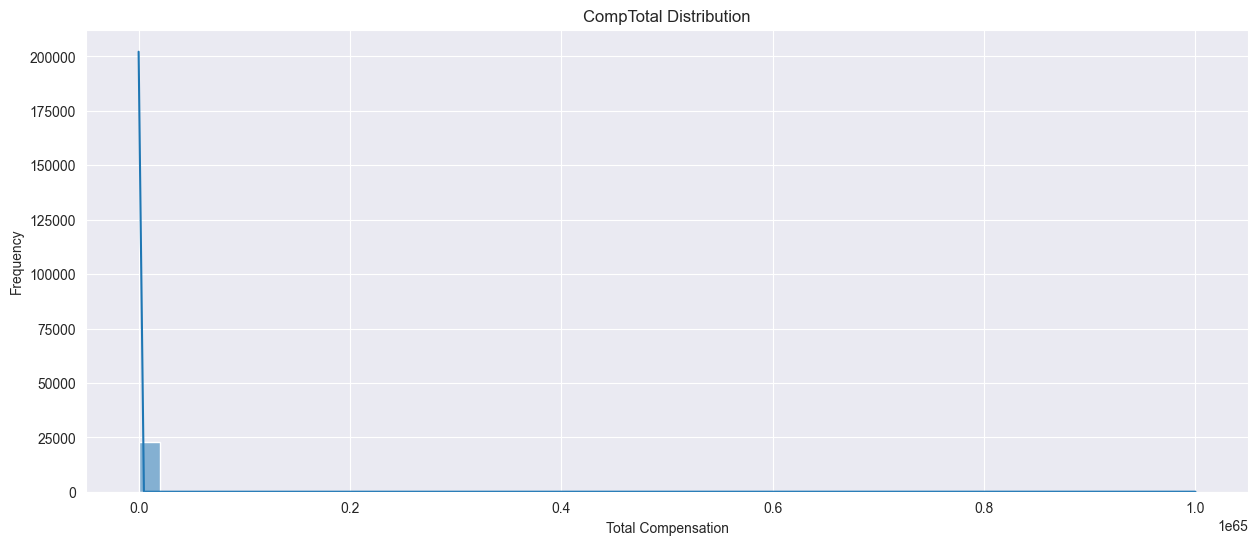

In [99]:
plt.figure(figsize=(15, 6))
sns.histplot(data=df_filtered, x='CompTotal', bins=50, kde=True)
plt.title("CompTotal Distribution")
plt.xlabel("Total Compensation")
plt.ylabel("Frequency")
plt.show()

# Fix the dataset

# Visualizing Relationships in Data
Scatter Plots
Create a scatter plot of Age and WorkExp.

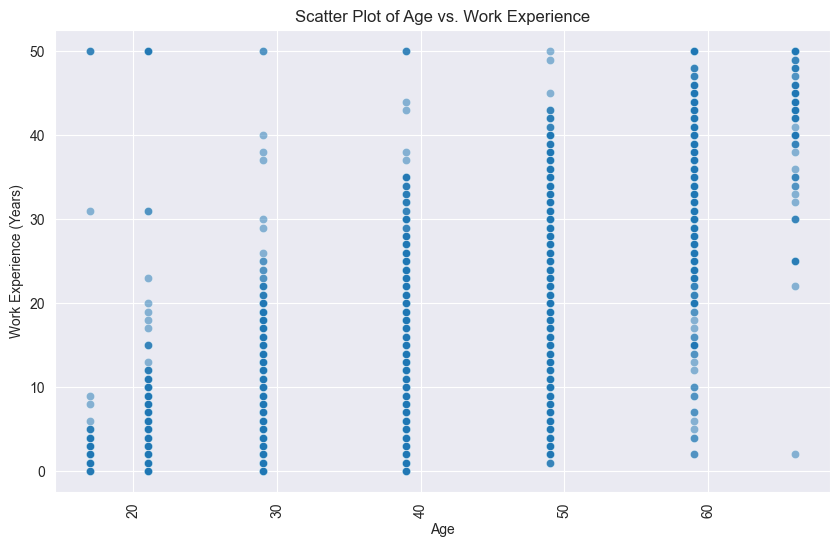

In [100]:
# Remove NaN values to avoid errors
df_filtered = df.dropna(subset=['Age', 'WorkExp'])

# Create Scatter Plot
plt.figure(figsize=(10, 6))  # Set figure size
sns.scatterplot(data=df_filtered, x='Age', y='WorkExp', alpha=0.5)  # alpha for transparency

# Add Labels and Title
plt.xlabel("Age")
plt.ylabel("Work Experience (Years)")
plt.title("Scatter Plot of Age vs. Work Experience")
plt.xticks(rotation=90)
# plt.grid(True) 
plt.show()

# Bubble Plots
Create a bubble plot of TimeSearching and Frustration using the Age column as the bubble size.

In [154]:
import numpy as np
def age_distribution(column):
    if '65 years or older' in column:
        return 66
    elif 'Under 18 years old' in column:
        return 17
    elif 'Prefer not to say' in column:
        return np.nan
    else:
        other_ages = column.split(' years old')
        age_split = other_ages[0].split('-')
        start_age = int(age_split[0])
        end_age = int(age_split[1])
        return (start_age + end_age)//2
df['Age'] = df['Age'].apply(age_distribution)

TypeError: argument of type 'float' is not iterable

In [119]:
df_buble = df.dropna(subset=['TimeSearching', 'Age', 'Frustration'])
df_buble.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
10,11,"I used to be a developer by profession, but no...",39.0,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,...,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0
12,13,I am a developer by profession,39.0,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,NaN,...,30.0,0.0,0.0,20.0,10.0,10.0,Appropriate in length,Easy,NaN,8.0
15,16,I am a developer by profession,49.0,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,5.0
18,19,I am a developer by profession,29.0,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Books;Stack Over...,...,60.0,10.0,10.0,0.0,0.0,0.0,Appropriate in length,Easy,NaN,10.0
20,21,"I am not primarily a developer, but I write co...",29.0,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Other online resources (e.g., videos, blogs, f...",Written Tutorials;Stack Overflow;Interactive t...,...,100.0,90.0,90.0,100.0,90.0,100.0,Appropriate in length,Easy,NaN,6.0


In [120]:
df['Age']

0        17.0
1        39.0
2        49.0
3        21.0
4        21.0
         ... 
65432    21.0
65433    29.0
65434    29.0
65435    21.0
65436    21.0
Name: Age, Length: 65437, dtype: float64

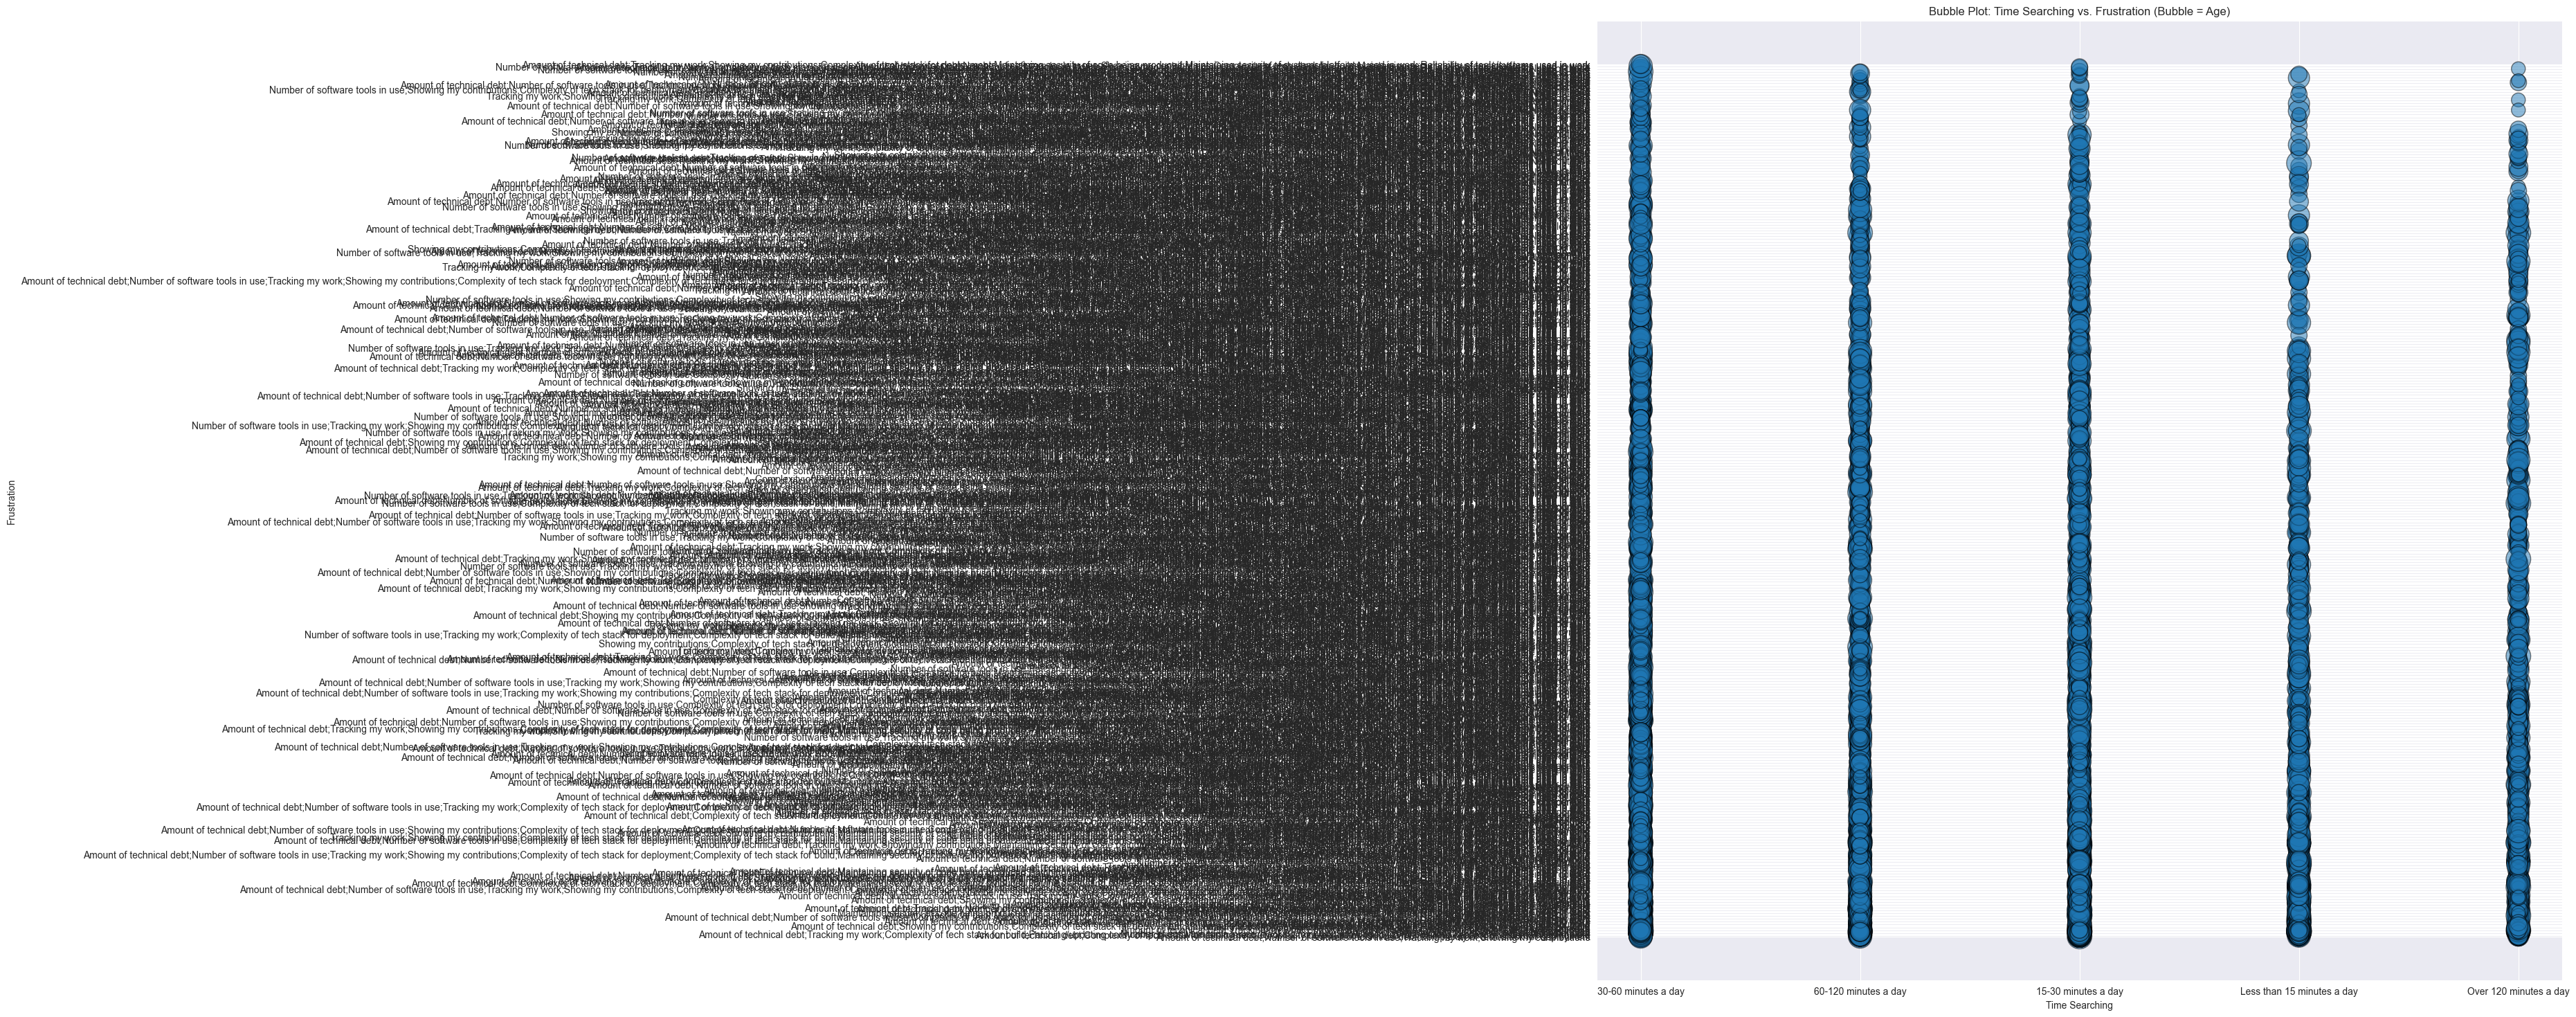

In [121]:
plt.figure(figsize=(18, 18))
plt.scatter(df_buble['TimeSearching'], df_buble['Frustration'], 
            s=df_buble['Age'] * 10, alpha=0.5, edgecolors='black')

plt.xlabel("Time Searching")
plt.ylabel("Frustration")
plt.title("Bubble Plot: Time Searching vs. Frustration (Bubble = Age)")
plt.grid(True)
plt.show()

# Visualizing Composition of Data
Pie Charts
Create a pie chart of the top 5 databases(DatabaseWantToWorkWith) that respondents wish to learn next year.

In [58]:
database = df["DatabaseWantToWorkWith"].value_counts()
pie_arr = {}
for data in range(5):
    pie_arr[database.index[data]] = database.iloc[data]
pie_arr

{'PostgreSQL': np.int64(3738),
 'PostgreSQL;SQLite': np.int64(1533),
 'SQLite': np.int64(1476),
 'Microsoft SQL Server': np.int64(1431),
 'MySQL': np.int64(1139)}

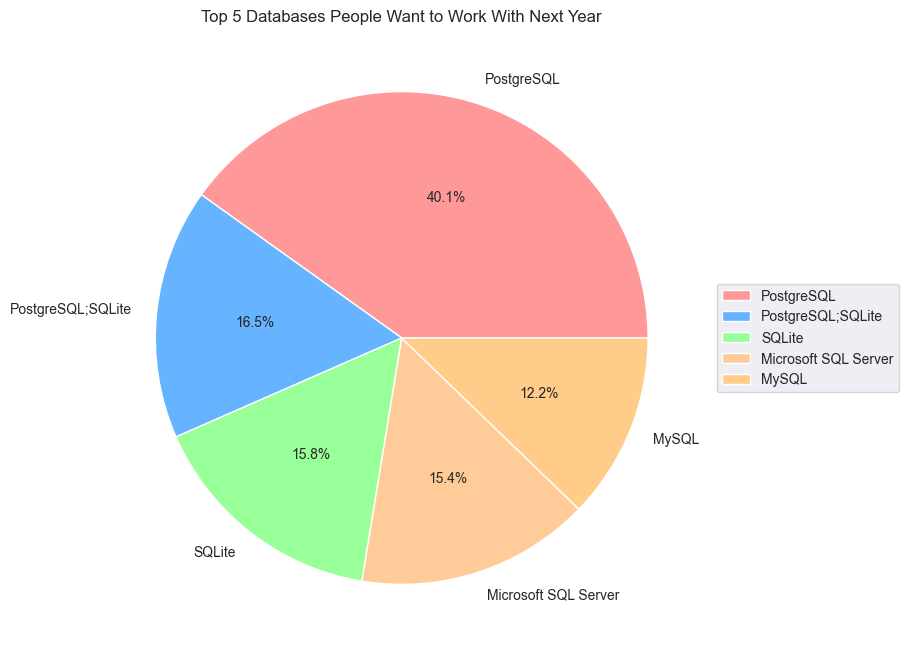

In [122]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#ffcc89']
plt.figure(figsize=(8, 8))
plt.pie(pie_arr.values(), labels=pie_arr.keys(), autopct='%1.1f%%', colors=colors)
plt.title("Top 5 Databases People Want to Work With Next Year")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Stacked Charts
Create a stacked bar chart of median TimeSearching and TimeAnswering for the age group 30 to 35.

In [125]:
import re
def convert_to_minutes(duration):
    if isinstance(duration, str):
        if 'Over' in duration:
            match = re.search(r'\d+', duration)
            if match:
                return int(match.group())
        elif 'Less than' in duration:
            match = re.search(r'\d+', duration)
            if match:
                return int(match.group())
        else:
            match = re.findall(r'\d+', duration)
            if match:
                return (sum(int(i) for i in match)) // len(match)

In [142]:
df['TimeAnswering'] = df['TimeAnswering'].apply(convert_to_minutes)
df['TimeAnswering'].value_counts()

TimeAnswering
22.0     9341
45.0     8642
15.0     5918
90.0     3704
120.0    1239
Name: count, dtype: int64

In [143]:
df['TimeSearching'] = df['TimeSearching'].apply(convert_to_minutes)
df['TimeSearching'].value_counts()

TimeSearching
45.0     10951
22.0      7805
90.0      5275
15.0      2689
120.0     2191
Name: count, dtype: int64

In [138]:
df['TimeSearching'].value_counts()

Series([], Name: count, dtype: int64)

In [131]:
age_group = df[(df['Age'] >= 30) & (df['Age'] <= 45)]

In [144]:
medians = age_group[[ 'TimeSearching', 'TimeAnswering']].median()
medians

TimeSearching    45.0
TimeAnswering    45.0
dtype: float64

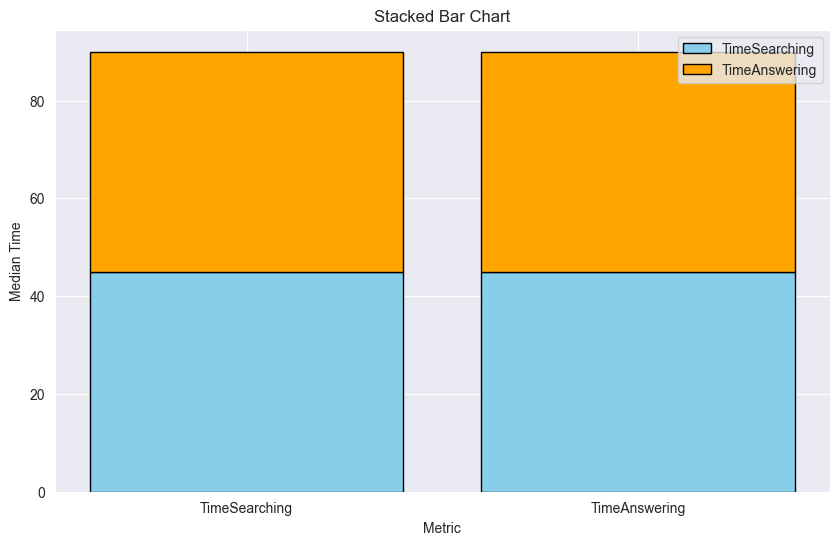

In [150]:
plt.figure(figsize=(10, 6))
plt.bar(medians.index, medians['TimeSearching'], label='TimeSearching', color='skyblue', edgecolor='black')
plt.bar(medians.index, medians['TimeAnswering'], label='TimeAnswering', bottom=medians['TimeSearching'] , color='orange', edgecolor='black')
plt.xlabel('Metric')
plt.ylabel('Median Time')
plt.title('Stacked Bar Chart')
plt.legend()
plt.show()

In [151]:
# Plot the median CompTotal for all ages from 45 to 60.

In [155]:
age_45_60_grouped = df[(df['Age'] >= 45) & (df['Age'] <= 60)]

In [158]:
df['CompTotal'] = df['CompTotal'].fillna(0)

In [159]:
find_comp_mis = df['CompTotal'].isnull().sum()
find_comp_mis

np.int64(0)

In [160]:
comp_medians = age_45_60_grouped[['CompTotal']].median()
comp_medians

CompTotal    131000.0
dtype: float64

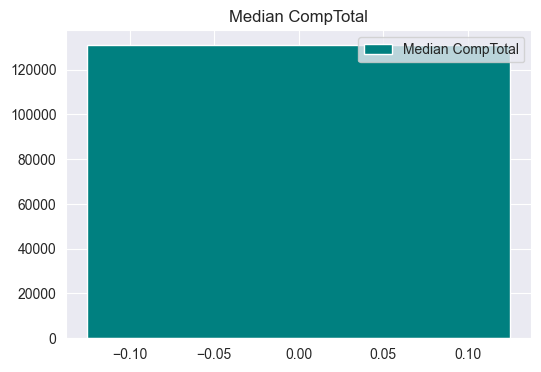

In [174]:

plt.figure(figsize=(6, 4))
plt.bar([0], comp_medians, color='teal', width=0.25) 
plt.legend(['Median CompTotal'])
plt.title("Median CompTotal")
plt.show()